<h1>Enhanced Two-Way Teleportation of Entangled
States with Six-Qubit Cluster State</h1>

In [2]:
#all required import statements
from qiskit import QuantumCircuit , QuantumRegister , ClassicalRegister
from qiskit_aer import AerSimulator , StatevectorSimulator
from qiskit.visualization import plot_histogram,plot_state_city
from qiskit.quantum_info import Statevector , state_fidelity, partial_trace
from random import randrange
from math import pi,sin,cos
import numpy as np

<h2>Generation and Verification of the Six-Qubit Cluster State</h2>
\[
|\psi_6\rangle = \tfrac{1}{2}\Big(
|000000\rangle +
|101010\rangle +
|010101\rangle +
|111111\rangle
\Big)
\]


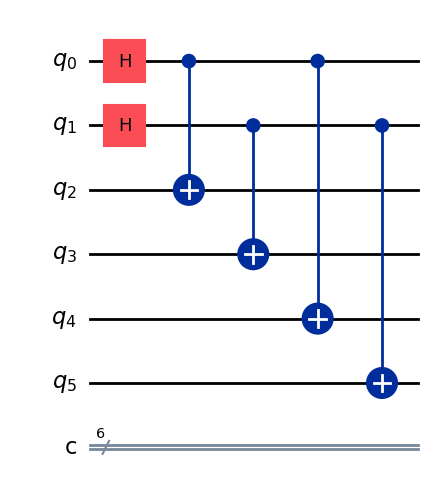

In [3]:
def six_qubit_cluster():
    qc = QuantumCircuit(6,name="Cluster6")
    qc.h([0,1])
    qc.cx(0,2)
    qc.cx(1,3)
    qc.cx(0,4)
    qc.cx(1,5)
    return qc
circ = six_qubit_cluster()
qreg = QuantumRegister(6, "q")
creg = ClassicalRegister(6, "c")
cluster_test = QuantumCircuit(qreg, creg)
cluster_test.compose(circ, qubits=qreg, inplace=True)
display(cluster_test.draw(output="mpl"))

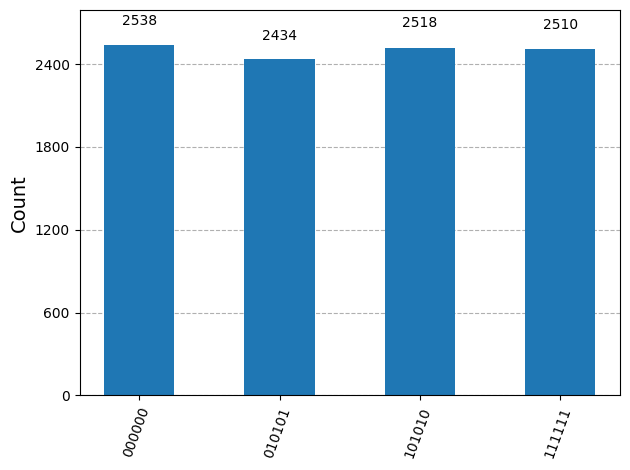

In [23]:
cluster_test.measure(qreg,creg)
job1=AerSimulator().run(cluster_test,shots=10000)
counts1 = job1.result().get_counts(cluster_test)
plot_histogram(counts1)

<h2>Preparation and Fidelity Testing of Alice’s and Bob’s Initial States </h2>

a0 = 0.90513847882371
a1 = (-0.13768617434396815+0.40220250067251273j)
targted state:  0.90513847882371 |00>  +  (-0.13768617434396815+0.40220250067251273j) |11>
Simulated statevector:
(0.90513847882371+0j)
0j
0j
(-0.13768617434396815+0.40220250067251273j)
Fidelity = 0.9999999999999998
✅ Fidelity is high (state preparation successful)


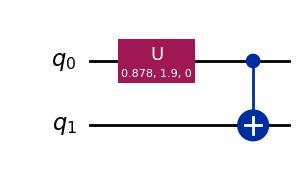

In [35]:
#Establishng test circuit 
Test=QuantumCircuit(2)
#setting the qubits to the initial state in the paper
theta_t = np.random.uniform(0, np.pi)
phi_t = np.random.uniform(0, 2*np.pi)
# First qubit in a0|0> + a1|1>
Test.u(theta_t, phi_t, 0, 0)
# CNOT to make a0|00> + a1|11>
Test.cx(0, 1)
# The amplitudes are:
a0 = np.cos(theta_t/2)
a1 = np.exp(1j*phi_t) * np.sin(theta_t/2)

#Define the targeted state vector
ideal = np.array([a0, 0, 0, a1], dtype=complex)
#calculate the actual state vector
state = Statevector.from_instruction(Test)
#Fidelity check
F = state_fidelity(state, ideal)

print("a0 =", a0)
print("a1 =", a1)
print("targted state: " ,a0,"|00>"," + ",a1,"|11>")
print("Simulated statevector:")
for amp in state:
    print(amp)
print("Fidelity =", F)
accepted_error = 1e-10  # acceptable numerical error
if F >= 1 - accepted_error:
    print(f"✅ Fidelity is high (state preparation successful)")
else:
    print(f"❌ Fidelity too low: something went wrong")
display(Test.draw('mpl'))

Alex_state 0.9663828723389175 |00> +  (0.16768921922660163+0.19489604871612012j) |11>
Bob_state 0.9219771604156061 |00> +  (0.3863725125865637-0.025969158429209542j) |11>


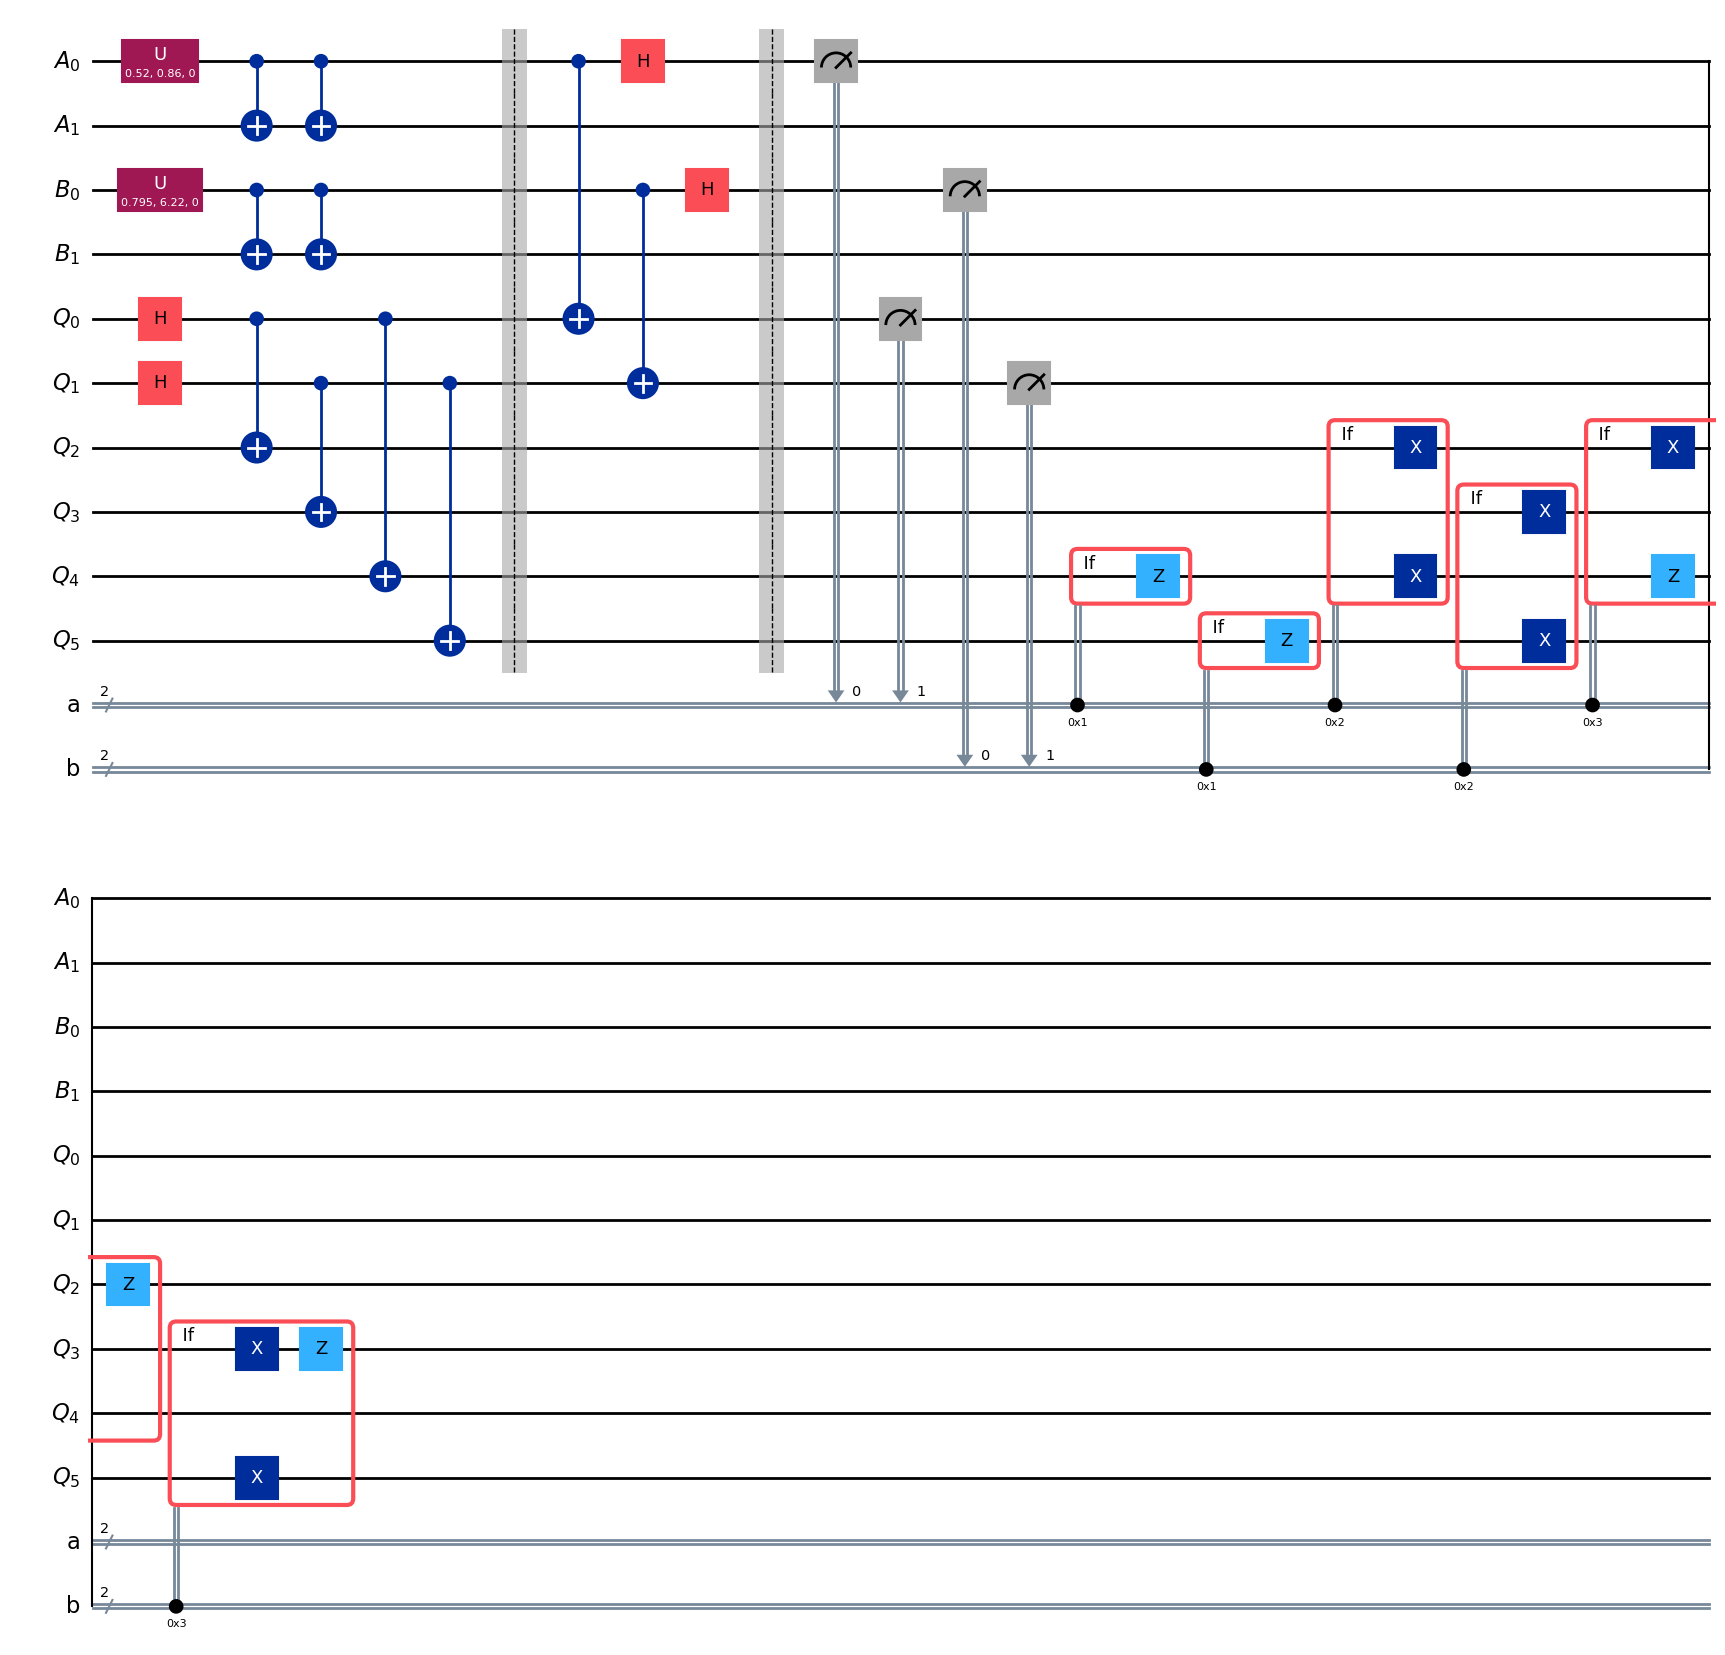

In [39]:
#circuit creation
A = QuantumRegister(2,'A')
B = QuantumRegister(2,'B')
c_a =ClassicalRegister(2,'a')#measures Alice's bell pair
c_b =ClassicalRegister(2,'b')#measures Bob's bell pair
cluster = QuantumRegister(6,'Q')
cluster_circ = six_qubit_cluster()
qc =QuantumCircuit(A,B, cluster,c_a,c_b)
#cluster channel preparation
qc.compose(cluster_circ, qubits=cluster, inplace=True)
#Alice initial state
theta_a = np.random.uniform(0, np.pi)
phi_a = np.random.uniform(0, 2*np.pi)
qc.u(theta_a, phi_a, 0, A[0])
qc.cx(A[0], A[1])
A0 = np.cos(theta_a/2)
A1 = np.exp(1j*phi_a) * np.sin(theta_a/2)
print("Alex_state",A0 ,"|00> + ",A1,"|11>")
#bob initial state
theta_b = np.random.uniform(0, np.pi)
phi_b = np.random.uniform(0, 2*np.pi)
qc.u(theta_b, phi_b, 0, B[0])
qc.cx(B[0], B[1])
B0 = np.cos(theta_b/2)
B1 = np.exp(1j*phi_b) * np.sin(theta_b/2)
print("Bob_state",B0 ,"|00> + ",B1,"|11>")
#ommiting the LSB for Alice and Bob
qc.cx(A[0],A[1])
qc.cx(B[0],B[1])
qc.barrier()
# preparing the entaglement for the bell mesurement
qc.cx(A[0],cluster[0])
qc.cx(B[0] , cluster[1])
qc.h([A[0],B[0]])
qc.barrier()
#Making Bell_measurement
qc.measure(A[0],c_a[0])
qc.measure(cluster[0],c_a[1])
qc.measure(B[0],c_b[0])
qc.measure(cluster[1],c_b[1])
#correction process_based on Table1 in the paper
#Bob_state
with qc.if_test((c_a, 1)):# outcome 01 -> |ϕ->
    qc.z(cluster[4])
with qc.if_test((c_a, 2)):# outcome 10 -> |ψ+>
    qc.x(cluster[2])
    qc.x(cluster[4])
with qc.if_test((c_a, 3)): # outcome 11 -> |ψ->
    qc.x(cluster[2])
    qc.z(cluster[2])
    qc.z(cluster[4])
#alice_state
with qc.if_test((c_b, 1)):   # outcome 01 -> |ϕ->
    qc.z(cluster[5])
with qc.if_test((c_b, 2)):   # outcome 10 -> |ψ+>
    qc.x(cluster[3])
    qc.x(cluster[5])
with qc.if_test((c_b, 3)):   # outcome 11 -> |ψ->
    qc.x(cluster[3])
    qc.z(cluster[3])
    qc.x(cluster[5])
qc.draw(output="mpl")